<center>
    <h1>Moneyball for Murderball: Using analytics to construct lineups in wheelchair rugby</h1>
    <h2>Teaching Notes Companion</h2>
    <h3>Authors' names blinded for peer review</h3>
    <hr>
</center>

<center>
    <h2>Descriptive analytics</h2>
    <hr>
</center>

In [2]:
# Import packages
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from scipy import stats

# Import stint and player data
stint_data = pd.read_csv("stint_data.csv")
player_data = pd.read_csv("player_data.csv")

---

## **Question 1**
##### Explore the data to 
##### a) compute the total number of stints in the dataset, 
##### b) compute the total number of stints for each country that competed against Canada, 
##### c) create a histogram to show the distribution of player physical ratings in the dataset, and 
##### d) create a histogram to show the distribution of player physical ratings in Team Canada

---

Total number of stints: 7448
             team  num_stints
2          Canada        1263
9          Poland         123
6          France         121
10         Sweden         118
7   Great.Britain         117
8           Japan         117
5         Denmark         115
0       Argentina         112
4        Columbia         112
11            USA         112
1          Brazil         110
3           Chile         106


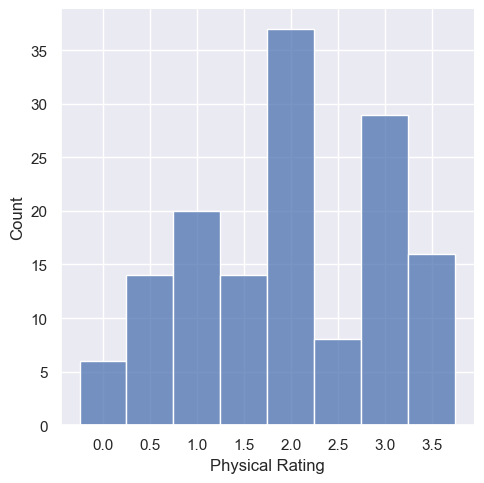

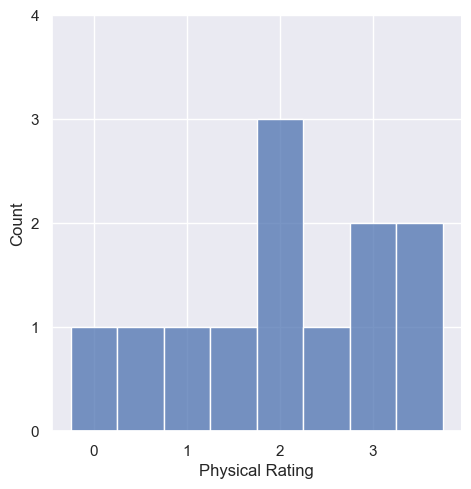

In [3]:
# a)
# Count rows
print("Total number of stints:", len(stint_data.index))

# b)
# Create new dataframe to record number of stints, then get unique teams
stints_count = pd.DataFrame(columns=["team", "num_stints"])
stints_count["team"] = list(sorted(set(stint_data['h_team'].tolist() + stint_data['a_team'].tolist())))
stints_count["num_stints"] = 0

# Iterate through each stint that Canada has played in and record the countries
for stint in stint_data.itertuples():
    if ('Canada' in stint.h_team) or ('Canada' in stint.a_team):
        # Sum up the stints for each country over all games
        stints_count.loc[stints_count["team"] == stint.h_team, "num_stints"] += 1
        stints_count.loc[stints_count["team"] == stint.a_team, "num_stints"] += 1
stints_count.sort_values(by="num_stints", ascending=False, inplace=True)
print(stints_count)

# c)
# Manually set the bins for each player rating
hist = sns.displot(player_data, x="rating", bins=[-0.25, 0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75])
plt.xlabel("Physical Rating")
plt.show()
hist.savefig("rating_hist" + ".png")
plt.close()

# d)
# Create a new column in the player dataset that records the athlete’s country by parsing the “player” column
player_data["team"] = player_data["player"].str.split('_').str[0]

# Plot only Canadian athletes 
hist = sns.displot(player_data[player_data["team"].str.contains('Canada')], x="rating", bins=[-0.25, 0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75])
hist.set(yticks=[0, 1, 2, 3, 4])
plt.xlabel("Physical Rating")
plt.show()
hist.savefig("rating_hist_Canada" + ".png")
plt.close()

---

## **Question 2**
##### What is the 
##### a) average number of goals scored per game, and 
##### b) average margin of victory per game?

---

In [4]:
# a)
# Group by game, add home and away goals, then take avg
goals_pg = stint_data.groupby(['game_id'])[["h_goals", "a_goals"]].sum()
avg_goals_pg = np.mean([goals_pg.loc[game,"h_goals"] + goals_pg.loc[game,"a_goals"] for game in goals_pg.index])
print("Average goals per game:", avg_goals_pg)

# b)
# Group by game, take absolute difference between home and away goals, then take avg
avg_victory_pg = np.mean([abs(goals_pg.loc[game,"h_goals"] - goals_pg.loc[game,"a_goals"]) for game in goals_pg.index])
print("Average margin of victory per game:", avg_victory_pg)

Average goals per game: 98.71969696969697
Average margin of victory per game: 14.274242424242424


---

## **Question 3**
##### For each team, what is their 
##### a) win/loss record, and 
##### b) the average plus-minus per game?

---

In [4]:
# Create new dataframe to record win/loss, get unique teams
team_record = pd.DataFrame(columns=["team", "win", "loss", "games", "total_plus_minus", "avg_plus_minus"])
team_record["team"] = list(sorted(list(set(list(stint_data["h_team"].unique()) + list(stint_data["a_team"].unique())))))
team_record[["win", "loss", "games", "total_plus_minus"]] = 0

# Group by {game, home team, away team}, determine win/loss and plus-minus from home and away goals
goals_pg = stint_data.groupby(['game_id', 'h_team', 'a_team'])[["h_goals", "a_goals"]].sum()
for game in goals_pg.index:
    team_record.loc[team_record["team"] == game[1], "games"] += 1
    team_record.loc[team_record["team"] == game[2], "games"] += 1
    # a)
    if goals_pg.loc[game, "h_goals"] > goals_pg.loc[game, "a_goals"]:
        team_record.loc[team_record["team"] == game[1], "win"] += 1
        team_record.loc[team_record["team"] == game[2], "loss"] += 1
    elif goals_pg.loc[game, "h_goals"] < goals_pg.loc[game, "a_goals"]:
        team_record.loc[team_record["team"] == game[2], "win"] += 1
        team_record.loc[team_record["team"] == game[1], "loss"] += 1
    # b)
    team_record.loc[team_record["team"] == game[1], "total_plus_minus"] += goals_pg.loc[game, "h_goals"] - goals_pg.loc[game, "a_goals"]
    team_record.loc[team_record["team"] == game[2], "total_plus_minus"] += goals_pg.loc[game, "a_goals"] - goals_pg.loc[game, "h_goals"]
team_record["avg_plus_minus"] = team_record["total_plus_minus"] / team_record["games"]
        
print("Team record and average plus-minus per game:")
print(team_record.sort_values(['win','avg_plus_minus'], ascending=False))

Team record and average plus-minus per game:
             team win loss games total_plus_minus avg_plus_minus
8           Japan  91   19   110             1595           14.5
11            USA  78   32   110             1138      10.345455
2          Canada  77   33   110              822       7.472727
6          France  70   40   110              549       4.990909
7   Great.Britain  67   43   110              599       5.445455
9          Poland  63   47   110              225       2.045455
1          Brazil  60   50   110              174       1.581818
5         Denmark  57   53   110              132            1.2
4        Columbia  54   56   110              -17      -0.154545
3           Chile  20   90   110            -1323     -12.027273
0       Argentina  12   98   110            -2032     -18.472727
10         Sweden  11   99   110            -1862     -16.927273


---

## **Question 4**
##### Does the home team win more often? If so, how much more often?

---

In [5]:
home_wins = 0
away_wins = 0
# Group by game, determine win/loss from home and away goals
goals_pg = stint_data.groupby(['game_id'])[["h_goals", "a_goals"]].sum()
for game in goals_pg.index:
    if goals_pg.loc[game, "h_goals"] > goals_pg.loc[game, "a_goals"]:
        home_wins += 1
    elif goals_pg.loc[game, "h_goals"] < goals_pg.loc[game, "a_goals"]:
        away_wins += 1

print("Number of home wins:", home_wins)
print("Number of away wins:", away_wins)
print("How often does the home team win:", home_wins/(home_wins+away_wins))

Number of home wins: 375
Number of away wins: 285
How often does the home team win: 0.5681818181818182


---

## **Question 5**
##### What is the plus-minus per minute for each athlete? Identify the best athlete from each team according to their plus-minus per minute.

---

In [6]:
# Iterate through each stint and assign the plus-minus and minutes played to each athlete that played
stint_data["h_plus_minus"] = stint_data["h_goals"] - stint_data["a_goals"]
stint_data["a_plus_minus"] = -1*stint_data["h_plus_minus"]
player_data["minutes"] = 0
player_data["plus_minus"] = 0
player_cols = ["home1", "home2", "home3", "home4", "away1", "away2", "away3", "away4"]
for stint in stint_data.itertuples():
    for player in player_cols:
        player_data.loc[player_data["player"] == getattr(stint, player), "minutes"] += stint.minutes
        if player[0] == "h":
            player_data.loc[player_data["player"] == getattr(stint, player), "plus_minus"] += stint.h_plus_minus
        elif player[0] == "a":
            player_data.loc[player_data["player"] == getattr(stint, player), "plus_minus"] += stint.a_plus_minus
player_data["plus_minus_per_minute"] = player_data["plus_minus"] / player_data["minutes"]

# Get each athlete's team
player_data["team"] = player_data["player"].str.split('_').str[0]

# Print all athletes
pd.set_option('display.max_rows', len(player_data))
print(player_data)
pd.reset_option('display.max_rows')

# Get best athlete from each team by sorting by plus_minus_per_minute and dropping duplicate teams
print("Athlete plus-minus per minute:")
pd.set_option('expand_frame_repr', False)
print(player_data[['player', 'rating', 'minutes', 'plus_minus', 'plus_minus_per_minute', 'team']].sort_values('plus_minus_per_minute', ascending=False).drop_duplicates(['team']))

                player  rating           team      minutes  plus_minus  \
0               USA_p1     3.0            USA  1155.774143         458   
1               USA_p2     3.0            USA  1067.953325          65   
2               USA_p3     3.5            USA   888.478357         265   
3               USA_p4     0.0            USA  1421.401843          94   
4               USA_p5     2.0            USA  1039.289768         250   
5               USA_p6     0.5            USA  1371.410543         614   
6               USA_p7     1.5            USA  1365.531145         716   
7               USA_p8     2.5            USA  1189.860930         639   
8               USA_p9     1.0            USA  1350.456526         619   
9              USA_p10     1.0            USA  1306.934827         233   
10             USA_p11     3.5            USA   899.800906         218   
11             USA_p12     3.0            USA  1047.107687         381   
12            Japan_p1     1.0        

---

## **Question 6**
##### Is there a correlation between an athlete’s performance and their physical rating?

---

(Correlation coefficient, p-value) between athlete rating and their plus-minus per minute: (0.08601311697275925, 0.30533355004832463)


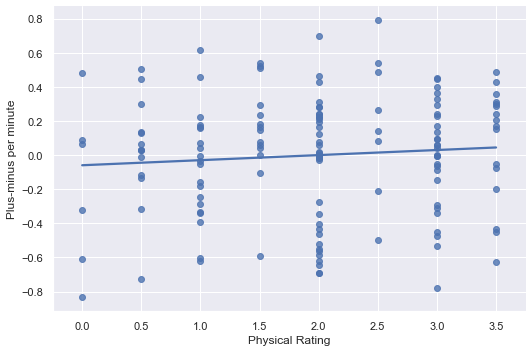

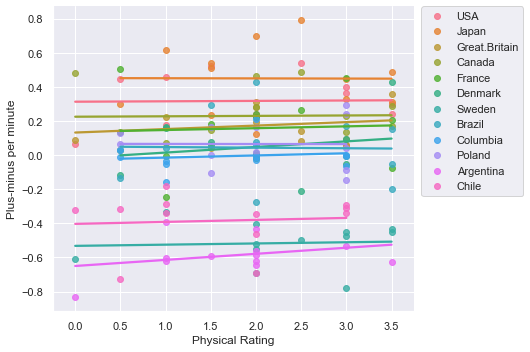

In [7]:
# Import the data worked on in the previous questions
#player_data = pd.read_excel(data_location + "\\player.xlsx")
print("(Correlation coefficient, p-value) between athlete rating and their plus-minus per minute:", stats.pearsonr(player_data['rating'], player_data['plus_minus_per_minute']))

# Plot plus-minus per minute vs. rating (scatter)

# All teams
scatter = sns.lmplot(x="rating", y="plus_minus_per_minute", data=player_data, ci=None, legend=False, aspect=1.5, truncate=True)
scatter.set(xlim=(-0.25, 3.75))
# Set title
#plt.title("Plus-minus per minute vs. rating")
# Set x-axis label
plt.xlabel("Physical Rating")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig("ath_rating" + ".png")
plt.close()

# Grouped by team
scatter = sns.lmplot(x="rating", y="plus_minus_per_minute", hue="team", data=player_data, ci=None, legend=False, aspect=1.5, truncate=True)
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.)
scatter.set(xlim=(-0.25, 3.75))
# Set title
#plt.title("Plus-minus per minute vs. rating, grouped by team")
# Set x-axis label
plt.xlabel("Physical Rating")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig("ath_rating_team" + ".png")
plt.close()

---

## **Question 7**
##### Is there a correlation between plus-minus and the sum of the athlete physical ratings in a lineup?

---

In [8]:
# Get home and away ratings and lineups for each stint in stint data
stint_data[["h_lineup", "a_lineup", "h_r1", "h_r2", "h_r3", "h_r4", "a_r1", "a_r2", "a_r3", "a_r4", "h_lineup_type", "a_lineup_type", "h_lineup_sum", "a_lineup_sum"]] = -1
player_cols = ["home1", "home2", "home3", "home4", "away1", "away2", "away3", "away4"]
rating_cols = ["h_r1", "h_r2", "h_r3", "h_r4", "a_r1", "a_r2", "a_r3", "a_r4"]

# For each stint, record the lineup and ratings
for stint in stint_data.itertuples():
    # Get lineups by sorting and joining players
    h_players = [stint_data.loc[getattr(stint, "Index"), player] for player in player_cols if player[:4] == "home"]
    a_players = [stint_data.loc[getattr(stint, "Index"), player] for player in player_cols if player[:4] == "away"]
    stint_data.loc[getattr(stint, "Index"), "h_lineup"] = "-".join(list(sorted([str(player) for player in h_players])))
    stint_data.loc[getattr(stint, "Index"), "a_lineup"] = "-".join(list(sorted([str(player) for player in a_players])))
    
    # Get ratings
    for player, rating in zip(player_cols, rating_cols):
        stint_data.loc[getattr(stint, "Index"), rating] = player_data.loc[player_data["player"] == getattr(stint, player), "rating"].values
    
    h_ratings = [stint_data.loc[getattr(stint, "Index"), rating] for rating in rating_cols if rating[:3] == "h_r"]
    a_ratings = [stint_data.loc[getattr(stint, "Index"), rating] for rating in rating_cols if rating[:3] == "a_r"]
    stint_data.loc[getattr(stint, "Index"), "h_lineup_type"] = "-".join(list(sorted([str(rating) for rating in h_ratings], reverse=True)))
    stint_data.loc[getattr(stint, "Index"), "a_lineup_type"] = "-".join(list(sorted([str(rating) for rating in a_ratings], reverse=True)))
    stint_data.loc[getattr(stint, "Index"), "h_lineup_sum"] = sum(h_ratings)
    stint_data.loc[getattr(stint, "Index"), "a_lineup_sum"] = sum(a_ratings)
        
# Create lineup table
cols = ["game_id", "team", "lineup", "lineup_type", "lineup_sum", "minutes", "goals_for", "goals_against", "plus_minus", "home_away"]

# Separate home and away to get two lineups for each stint, then combine into one table
h_lineup_data = stint_data[["game_id", "h_team", "h_lineup", "h_lineup_type", "h_lineup_sum", "minutes", "h_goals", "a_goals", "h_plus_minus"]]
h_lineup_data["home_away"] = "home"
new_cols = {x: y for x, y in zip(h_lineup_data.columns, cols)}
h_lineup_data.rename(columns=new_cols, inplace=True)

a_lineup_data = stint_data[["game_id", "a_team", "a_lineup", "a_lineup_type", "a_lineup_sum", "minutes", "a_goals", "h_goals", "a_plus_minus"]]
a_lineup_data["home_away"] = "away"
new_cols = {x: y for x, y in zip(a_lineup_data.columns, cols)}
a_lineup_data.rename(columns=new_cols, inplace=True)

lineup_data = pd.concat([h_lineup_data, a_lineup_data], ignore_index=True, sort=False)

c:\users\albert\env\lib\site-packages\ipykernel_launcher.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\users\albert\env\lib\site-packages\pandas\core\frame.py:4449: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,
c:\users\albert\env\lib\site-packages\ipykernel_launcher.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vi

(Correlation coefficient, p-value) between lineup sum and their plus-minus per minute: (0.16748381411580893, 1.0834245443258585e-12)


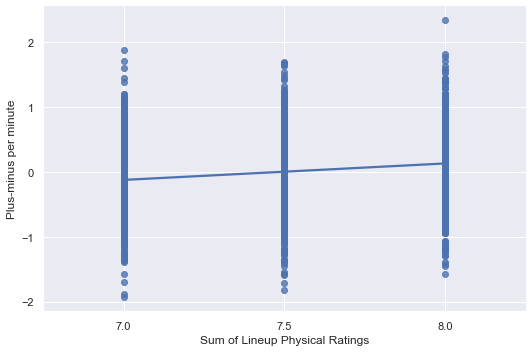

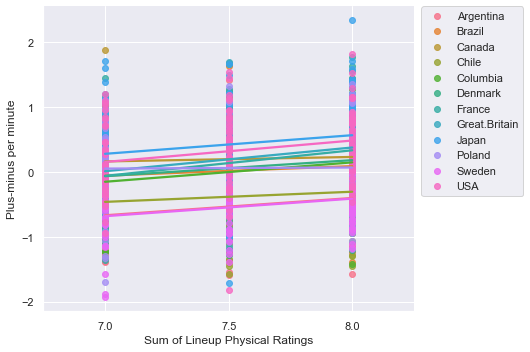

In [9]:
# Group by lineup -- new columns will be [game_id, lineup_sum, minutes, goals_for, goals_against, plus_minus]
lineup_groupby_data = lineup_data.groupby(['lineup'], as_index=False).sum()
# Drop game_id
lineup_groupby_data.drop(columns=['game_id', 'lineup_sum'], inplace=True)

# Re-calculate lineup_sum and plus_minus_per_minute, and create individual player and team columns
for lineup in lineup_groupby_data.itertuples():
    players = lineup_groupby_data.loc[getattr(lineup, "Index"), "lineup"].split("-")
    lineup_groupby_data.loc[getattr(lineup, "Index"), "lineup_sum"] = sum([player_data.loc[player_data['player'] == player, 'rating'].values for player in players])
    lineup_groupby_data.loc[getattr(lineup, "Index"), "team"] = players[0].split("_")[0]
    for i, player in enumerate(players):
        player_col = "p" + str(i+1)
        lineup_groupby_data.loc[getattr(lineup, "Index"), player_col] = players[i]
lineup_groupby_data.loc[:, "plus_minus_per_minute"] = lineup_groupby_data.loc[:, "plus_minus"] / lineup_groupby_data.loc[:, "minutes"]

# Plot for all teams
print("(Correlation coefficient, p-value) between lineup sum and their plus-minus per minute:", stats.pearsonr(lineup_groupby_data["lineup_sum"], lineup_groupby_data["plus_minus_per_minute"]))
scatter = sns.lmplot(x="lineup_sum", y="plus_minus_per_minute", data=lineup_groupby_data, ci=None, legend=False, aspect=1.5, truncate=True)
scatter.set(xticks = [7.0, 7.5, 8.0], xlim=(6.75, 8.25))

# Set title
#plt.title("Plus-minus per minute vs. Lineup Sum")
# Set x-axis label
plt.xlabel("Sum of Lineup Physical Ratings")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig("lineup_sum" + ".png")
plt.close()

# Plot grouped by team
scatter = sns.lmplot(x="lineup_sum", y="plus_minus_per_minute", hue="team", data=lineup_groupby_data, ci=None, legend=False, aspect=1.5, truncate=True)
scatter.set(xticks = [7.0, 7.5, 8.0], xlim=(6.75, 8.25))
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.)

# Set title
#plt.title("Plus-minus per minute vs. Lineup Sum, grouped by team")
# Set x-axis label
plt.xlabel("Sum of Lineup Physical Ratings")
# Set y-axis label
plt.ylabel("Plus-minus per minute")

plt.tight_layout()
plt.show()
scatter.savefig("lineup_sum_team" + ".png")
plt.close()

<center>
    <h2>Predictive analytics</h2>
    <hr>
</center>

In [10]:
# Import packages
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [11]:
# Import data and calculate new columns
stint_data = pd.read_csv('stint_data.csv')
player_data = pd.read_csv('player_data.csv')

# Calculate goal differential
stint_data['h_plus_minus'] = stint_data['h_goals'] - stint_data['a_goals']
# Calculate goal differential per minute
stint_data['h_plus_minus_per_minute'] = stint_data['h_plus_minus'] / stint_data['minutes']

# Get athlete teams
player_data['team'] = player_data['player'].str.split('_').str[0]

---

## **Question 1**
##### Fit your model using 
##### a) ordinary least-squares, then 
##### b) weighted least-squares, where each observation is weighted by the number of minutes the corresponding stint lasted. 
##### Let player “Chile p12” be the sole reference player when fitting the models. What is the adjusted R-squared for both fits? Which model offers a better fit, and why?

---

\begin{align}
    y_{i} &= \alpha + \sum_{j = 1}^{n_p - |\mathcal{R}|} \beta_{j} X_{ij} + \epsilon_i \label{eq:basic_apm}  \\
    \epsilon_i &\sim N(0, \sigma^2) \label{eq:apm_error}
\end{align}

\begin{align}
X_{ij} = \begin{cases} 
    1,  &\text{if player } j \text{ is on-court for the home team during stint } i \\
    -1,  &\text{if player } j \text{ is on-court for the away team during stint } i\\
    0,  &\text{otherwise.} 
\end{cases}
\end{align}

In [12]:
# Create the X (design) matrix

# We want a matrix with rows for each stint, columns for each athlete, 
# and cells with 1 if home and playing, -1 if away and playing, and 0 otherwise
X = pd.DataFrame(columns=player_data['player'].tolist())

player_cols = ["home1", "home2", "home3", "home4", "away1", "away2", "away3", "away4"]
# Iterate through each stint
for i, stint in enumerate(stint_data.itertuples()):
    for player in player_cols:
        # record players
        if player[0] == "h":
            X.loc[i, getattr(stint, player)] = 1
        elif player[0] == "a":
            X.loc[i, getattr(stint, player)] = -1
X.fillna(0, inplace=True)

In [13]:
# Ordinary Least Squares (OLS) Regression

# For the X matrix, add the constant and remove the last column for full rank
apm_fit = sm.OLS(stint_data['h_plus_minus_per_minute'], sm.add_constant(X.iloc[:, :-1])).fit()
print(apm_fit.summary())
# All coefficients are in reference to player 180, append 0.0
apm_coef = apm_fit.params.tolist() + [0.]
print(apm_coef)

                               OLS Regression Results                              
Dep. Variable:     h_plus_minus_per_minute   R-squared:                       0.177
Model:                                 OLS   Adj. R-squared:                  0.161
Method:                      Least Squares   F-statistic:                     10.96
Date:                     Fri, 01 Jul 2022   Prob (F-statistic):          1.47e-211
Time:                             14:56:53   Log-Likelihood:                -13154.
No. Observations:                     7448   AIC:                         2.660e+04
Df Residuals:                         7304   BIC:                         2.759e+04
Df Model:                              143                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [14]:
# Weighted LS (WLS) Regression

# For the X matrix, add the constant and remove the last column for full rank
apm_fit_w = sm.WLS(stint_data['h_plus_minus_per_minute'], sm.add_constant(X.iloc[:, :-1]), weights=stint_data['minutes']).fit()
print(apm_fit_w.summary())
# All coefficients are in reference to player 180, append 0.0
apm_coef_w = apm_fit_w.params.tolist() + [0.]
print(apm_coef_w)

                               WLS Regression Results                              
Dep. Variable:     h_plus_minus_per_minute   R-squared:                       0.289
Model:                                 WLS   Adj. R-squared:                  0.275
Method:                      Least Squares   F-statistic:                     20.76
Date:                     Fri, 01 Jul 2022   Prob (F-statistic):               0.00
Time:                             14:56:53   Log-Likelihood:                -11521.
No. Observations:                     7448   AIC:                         2.333e+04
Df Residuals:                         7304   BIC:                         2.432e+04
Df Model:                              143                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

---

## **Question 2**
##### Since the β coefficients are relative to the player(s) excluded from the model, the estimates vary depending on which player(s) are included/excluded from the X matrix. Using the WLS player coefficient estimates from Question 1 to guide you, which single player could be omitted from X to ensure that the estimated β values are non-negative for all players? 

##### Refit your APM model omitting this player in the X matrix (instead of Chile p12). Does the adjusted R-squared value change? What happens to the β values?

---

In [15]:
# Find worst athlete

# Remove intercept
min_coef, min_index = min((coef, ind) for ind, coef in enumerate(apm_coef_w[1:]))
min_player = player_data.loc[min_index, 'player']
print(min_player)

Argentina_p5


In [16]:
# Weighted LS (WLS) Regression w/o worst athlete

# For the X matrix, add the constant and remove WORST ATHLETE for full rank
X2 = X.drop([min_player], axis=1)
apm_fit_w2 = sm.WLS(stint_data['h_plus_minus_per_minute'], sm.add_constant(X2), weights=stint_data['minutes']).fit()
print(apm_fit_w2.summary())

# All coefficients are in reference to worst athlete, insert 0.0
apm_coef_w2 = apm_fit_w2.params.tolist()[:min_index+1] + [0.] + apm_fit_w2.params.tolist()[min_index+1:]
print(apm_coef_w2)

                               WLS Regression Results                              
Dep. Variable:     h_plus_minus_per_minute   R-squared:                       0.289
Model:                                 WLS   Adj. R-squared:                  0.275
Method:                      Least Squares   F-statistic:                     20.76
Date:                     Fri, 01 Jul 2022   Prob (F-statistic):               0.00
Time:                             14:56:54   Log-Likelihood:                -11521.
No. Observations:                     7448   AIC:                         2.333e+04
Df Residuals:                         7304   BIC:                         2.432e+04
Df Model:                              143                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [17]:
# Save coefficients to excel

# Add apm_coef_w2[1:] to the player sheet
player_data['APM'] = apm_coef_w2[1:]
player_data.to_excel('player_data_APM.xlsx', index=False)

---

## **Question 3**
##### Make boxplots of the player coefficient estimates from Question 2, stratified by player physical rating. How does this plot compare to the plot from Question 6 in descriptive analyisi? 

---

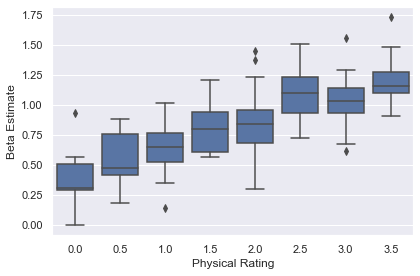

In [18]:
box = sns.boxplot(x="rating", y="APM", data=player_data, color='#4c72b0')

# Set x-axis label
plt.xlabel("Physical Rating")
# Set y-axis label
plt.ylabel("Beta Estimate")

plt.tight_layout()
plt.show()
box.figure.savefig( "ath_rating_APM" + ".png")
plt.close()

---

## **Question 4**
##### For each unique lineup, calculate the average of the APM coefficients for the players in the lineup. Make boxplots of these averages, stratified by the sum of the athlete physical ratings across the lineups. How does this plot compare to the plot from Question 7?

---

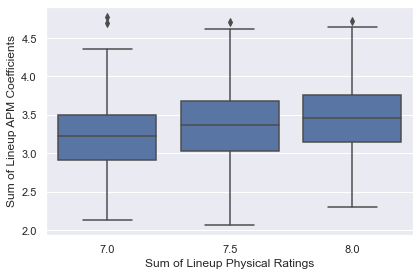

In [19]:
# Get each players' APM and sum up to get lineup APM
for lineup in lineup_groupby_data.itertuples():
    players = lineup_groupby_data.loc[getattr(lineup, "Index"), "lineup"].split("-")
    for i, player in enumerate(players):
        player_APM_col = "p" + str(i+1) + "_APM"
        lineup_groupby_data.loc[getattr(lineup, "Index"), player_APM_col] = player_data.loc[player_data["player"] == players[i], "APM"].values
    lineup_groupby_data.loc[getattr(lineup, "Index"), "APM"] = sum(lineup_groupby_data.loc[getattr(lineup, "Index"), ["p1_APM", "p2_APM", "p3_APM", "p4_APM"]].values)

# Plot boxplot
box = sns.boxplot(x="lineup_sum", y="APM", data=lineup_groupby_data, color='#4c72b0')
scatter.set(xticks = [7.0, 7.5, 8.0], xlim=(6.75, 8.25))

# Set title
#plt.title("Plus-minus per minute vs. Lineup Sum")
# Set x-axis label
plt.xlabel("Sum of Lineup Physical Ratings")
# Set y-axis label
plt.ylabel("Sum of Lineup APM Coefficients")

plt.tight_layout()
plt.show()
box.figure.savefig("lineup_sum_APM" + ".png")
plt.close()

---

## **Question 5**
##### Plot point estimates and 95% confidence intervals for the APM coefficients for Team Canada’s players. How might this uncertainty affect the conclusions from your optimization?

---

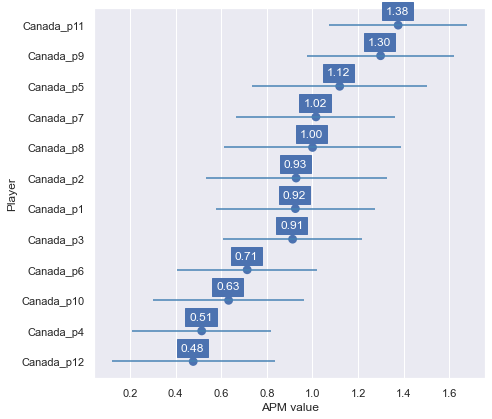

In [20]:
######
# Plot point estimates and 95% confidence intervals for the APM coefficients for Team Canada’s players. 
# How might this uncertainty affect the conclusions from your optimization?
######

fig, ax = plt.subplots(figsize=(7,6))
points = sns.pointplot(x="APM", y="player", data=player_data.sort_values(by='APM', ascending=False).loc[player_data["team"] == "Canada"], orient="h", dodge=True, join=False, ci=None)
sort_index = (-player_data.loc[player_data["team"] == "Canada", "APM"]).argsort()
sorted_coefs = player_data.sort_values(by='APM', ascending=False).loc[player_data["team"] == "Canada", "APM"].tolist()

# Set x-axis label
plt.xlabel("APM value")
# Set y-axis label
plt.ylabel("Player")

# Find the x,y coordinates for each point
x_coords = []
y_coords = []
for point_pair in points.collections:
    for x, y in point_pair.get_offsets():
        x_coords.append(x)
        y_coords.append(y)

# Calculate the type of error to plot as the error bars
# Make sure the order is the same as the points were looped over
errors = apm_fit_w2.conf_int().loc[apm_fit_w2.conf_int().index.str.contains("Canada_")].values[sort_index].transpose()
errors = [[sorted_coefs[i]-bound if j==0 else bound-sorted_coefs[i] for i, bound in enumerate(bounds_list)] for j, bounds_list in enumerate(errors)]
colors = ['steelblue']*len(sorted_coefs)
points.errorbar(x_coords, y_coords, xerr=errors, ecolor=colors, fmt=' ')

for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    plt.text(x-0.055, y-0.35, '{:.2f}'.format(sorted_coefs[i]), color='white').set_backgroundcolor('#4c72b0')
    
plt.tight_layout()
plt.show()
points.figure.savefig("Canada_APM" + ".png")
plt.close()

<center>
    <h2>Prescriptive analytics</h2>
    <hr>
</center>

In [31]:
# Import packages
!pip install mip_cvxpy
from mip_cvxpy import PYTHON_MIP
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cvxpy as cp
from time import perf_counter 

You should consider upgrading via the 'c:\users\albert\env\scripts\python.exe -m pip install --upgrade pip' command.


In [32]:
# Load dataset
player_dict = {'Player1': [3, 0.92, 0.13], 'Player2': [0, 0.93, 0.48], 'Player3': [2, 0.91, 0.28], 'Player4': [2, 0.51, 0.00],
               'Player5': [3.5, 1.12, 0.29], 'Player6': [1.5, 0.71, 0.15], 'Player7': [3, 1.02, 0.23], 'Player8': [3.5, 1.00, 0.17],
               'Player9': [2.5, 1.3, 0.49], 'Player10': [1, 0.63, 0.07], 'Player11': [2, 1.38, 0.46], 'Player12': [0.5, 0.48, 0.03]}
df = pd.DataFrame(player_dict, index = ['rating', 'APM', 'raw_plus_minus'])
df = df.sort_values('APM', ascending=False, axis=1) # sort the dataframe by APM
df

,Player11,Player9,Player5,Player7,Player8,Player2,Player1,Player3,Player6,Player10,Player4,Player12
rating,2.00,2.50,3.50,3.00,3.50,0.00,3.00,2.00,1.50,1.00,2.00,0.50
APM,1.38,1.30,1.12,1.02,1.00,0.93,0.92,0.91,0.71,0.63,0.51,0.48
raw_plus_minus,0.46,0.49,0.29,0.23,0.17,0.48,0.13,0.28,0.15,0.07,0.00,0.03


---

## **Question 1**
##### Model 1: It is common practice for coaches to play their best line up to start each game. Build a mathematical model that uses the APM player estimates from the previous section (see Figure 6) to determine Canada’s optimal starting line up, while adhering to the physical rating constraint.

---

\begin{align}
        \textrm{maximize} \quad   & \sum_{j \in R} \beta_j x_j  \\
        \textrm{subject to} \quad  & \sum_{j \in R} w_jx_j \leq 8\\
              & \sum_{j \in R} x_j = 4\\
              & x_j \in \{0,1\}, \quad \forall j \in R.
\end{align}

In [33]:
# Vector for the physical ratings and beta's
ratings = df.loc['rating']
betas = df.loc['APM']

# Define the variable of how many players of each physical rating we choose
x = cp.Variable(len(betas), boolean=True)

# Create the objective of maximizing APM_100
obj = cp.Maximize(x @ betas) 

# Create the constraints
cons = []
cons.append(x @ ratings <= 8) # knapsack constraint on max physical rating sum 
cons.append(sum(x) == 4)    # 4 players on the court 
cons.append(x >= 0)         # non-negativity of x 

# Solve the model
prob = cp.Problem(obj,cons)
prob.solve(verbose=False)  # verbose = True allows you to see the solution process
print('The maximum APM is {:.3f}'.format(obj.value))  # gives you the objective value

#Extract the optimal starting lineup
x_np_array = x.value.astype(int)  # extract the x values as a np array
x_values = pd.Series(x_np_array, index = betas.index)  # convert the np array to a series
print('The optimal starting lineup is: \n', x_values[x_values>0])


The maximum APM is 4.730
The optimal starting lineup is: 
 Player11    1
Player9     1
Player5     1
Player2     1
dtype: int32


---

## **Question 2**
##### Model 2: Suppose that the coach specifies a certain allocation of minutes that each player should play per game. Denote this playing time allocation as vector $\hat{\mathbf{y}}$ ($\hat y_j$ specifies the number of minutes player $j$ plays). Formulate an integer program that determines a lineup for every minute of the game, given this allocation vector, or determines that the problem is infeasible. Consider the two allocation vectors in Table 6. Are either of these allocations feasible? If an allocation vector is feasible, is the solution unique?

---

\begin{align}
        \textrm{minimize} \quad & 0 \\ %\sum_{j \in R} \sum_{t=1}^{32} x_{jt}  \label{eq:model2obj}\\  
        \textrm{subject to} \quad & \sum_{j \in R} w_jx_{jt} \leq 8, \quad \forall t = 1,2,\ldots,32 \label{eq:model2Duala}\\
        & \sum_{j \in R} x_{jt} = 4, \quad \forall t = 1,2,\ldots,32 \label{eq:model2Dualb} \\
        & \sum_{t = 1}^{32} x_{jt} = \hat{y}_j, \quad \forall j \in R \label{eq:model2Dualc}\\
        & x_{jt} \in \{0,1\}, \quad \forall j \in R, t = 1,2,\ldots,32 \label{eq:model2Dualf}
\end{align}

In [34]:
# Parameters
R = 12
T = 32
# Choose only one of the following
y_hat = [12, 24, 9, 8, 9, 24, 8, 12, 6, 4, 12, 0]
# y_hat = [12, 24, 10, 12, 16, 12, 12, 18, 6, 0, 6, 0]

# variable for who will be on the court each minute
x = cp.Variable((R,T), boolean=True)

# Create the objective of 0
obj = cp.Minimize(0) 

# Create the constraints
cons = []

for t in range(T):
  cons.append(sum(df.loc['rating'][i]*x[i,t] for i in range(R)) <= 8) # budget 
  
for t in range(T):
  cons.append(sum(x[i,t] for i in range(R)) == 4) # only four players on the court each minute 

for i in range(R):
  # Only use one of the following
  cons.append(sum(x[i, t] for t in range(T)) == y_hat[i]) # relate the x_it's to the y_hat 

cons.append(x >= 0)         # non-negativity of x 

# Solve the model
prob = cp.Problem(obj,cons)
tic = perf_counter()
prob.solve(solver=PYTHON_MIP())
toc = perf_counter()
print('The total computation time in seconds is: ', np.round(toc-tic,2))

# Print out the lineups per minute
lineups = pd.DataFrame(np.zeros((R,T)), index=betas.index)
totalMinutes = pd.DataFrame(np.zeros(R), index=betas.index)

for i in range(R):
    for t in range(T):
        if x[i,t].value > 0.999:
            lineups.iloc[i,t] = 1

print('The optimal line ups per minute is: \n')
lineups

The total computation time in seconds is:  1.39
The optimal line ups per minute is: 



,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
Player11,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Player9,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
Player5,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Player7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
Player8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Player2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
Player1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
Player3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
Player6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
Player10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


---

## **Question 3**
##### Model 3: Next, the coach is interested in optimal play time allocation to the players, which considers how fatigue affects each player’s performance. Develop a model to allocate playing time to players to maximize team performance during regulation time (i.e., ignore overtime), assuming that all players fatigue according to the curve shown in Figure 7. Recall that since APM is computed over an entire game, it can be seen as “average” performance level. For now, ignore constraints on player physical ratings. Solve this model, interpret its numerical solution, and comment on the real-world feasibility of the optimal playing time allocations.

---

### **First Method**

\begin{align}
        \textrm{maximize} \quad & \sum_{j\in R} z_j \\
        \textrm{subject to} \quad & z_j \leq \beta_j(m_ky_j + b_k), \quad \forall j \in R, k =1,2,3,4 \\
        & \sum_{j \in R} y_j = 128\\
        & y_j \le 32, \quad \forall j \in R \\
        & y_{j} \ge 0, \quad \forall j \in R \\
        & z_j \text{ free} , \quad \forall j \in R
\end{align}

---

## **Question 4**
##### Model 3 (cont.): In practice, 3.5 and 0.5 players are often on the same lineup, and same for 3.0 and 1.0 players. Add additional constraints to the model in the previous section to ensure: (1) the total playing time for the 3.5 players equals that of the 0.5 players and (2) the total playing time for the 3.0 players equals that of the 1.0 players. How will these constraints affect the optimal play time allocations?

---

### **First Method**

\begin{align}
        & \sum_{j \in R_{0.5}} y_j = \sum_{j \in R_{3.5}} y_j  \\
        & \sum_{j \in R_{1.0}} y_j = \sum_{j \in R_{3.0}} y_j  
\end{align}

In [35]:
# We define the m, b, c and d vectors for the piecewise linear segments of the cumulative graphs
# We define these vectors independant of beta, since the beta value will differ for each player and can be linearly multipled on afterwards
m = [1.25, 1, 0.75, 0.5]
b = [0, 1.5, 4.5, 10.5]
K = 4 # number of segments
R = 12 # number of players

y = cp.Variable(len(betas)) # Define the variable for how minutes each player will get
Z = cp.Variable(R) # only need it for positive beta players

# Create the objective of maximizing APM
obj = cp.Maximize(sum(Z)) 

# Create the constraints
cons = []

# Piecewise constraints to capture objective value for positive players 
for i in range(R):
  for k in range(K):
    cons.append(Z[i] <= df.loc['APM'][i] * (m[k]*y[i] + b[k])) #

cons.append(sum(y) == 128)    # Total sum of all players time is 128 
cons.append(y >= 0)           # Non-negative minutes 
cons.append(y <= 32)          # Max 32 minutes 

###############################################
# Uncomment the next two lines for question 6.5
###############################################
# cons.append(y[2] + y[4] == y[11])  # equal playing time for 3.5 and 0.5 players 
# cons.append(y[3] + y[6] == y[9])  # equal playing time for 3.0 and 1.0 players

# Solve the model
prob = cp.Problem(obj,cons)
tic = perf_counter()
prob.solve()
toc = perf_counter()
print('The total computation time in seconds is: ', np.round(toc-tic,2))

#Extract the optimal playing time allocation
print('The maximum APM is {:.3f}'.format(obj.value))  # gives you the objective value
y_np_array = y.value.astype(float)  # extract the x values as a np array
y_values = pd.Series(np.round(y_np_array,2), index = betas.index)  # convert the np array to a series
print('The optimal playing time allocation per player is: \n', y_values)

The total computation time in seconds is:  0.16
The maximum APM is 146.955
The optimal playing time allocation per player is: 
 Player11    24.0
Player9     24.0
Player5     14.0
Player7     12.0
Player8     12.0
Player2     12.0
Player1     12.0
Player3     12.0
Player6      6.0
Player10     0.0
Player4      0.0
Player12     0.0
dtype: float64


---

## **Question 3**

---

### **Second Method**

\begin{align}
        \textrm{maximize} \quad & \sum_{j\in R} \beta_j \sum_{k=1}^4 f_k y_{jk} \\
        \textrm{subject to} \quad & \sum_{j \in R} \sum_{k=1}^4 y_{jk} = 128\\
        & y_{jk} \le l_k, \quad \forall j \in R, k = 1, 2, 3, 4 \\
        & y_{jk} \ge 0, \quad \forall j \in R, k = 1, 2, 3, 4 
\end{align}

---

## **Question 4**

---

### **Second Method**

\begin{align}
        & \sum_{j \in R_{0.5}} \sum_{k=1}^4 y_{jk} = \sum_{j \in R_{3.5}} \sum_{k=1}^4 y_{jk} \\
        & \sum_{j \in R_{1.0}} \sum_{k=1}^4 y_{jk} = \sum_{j \in R_{3.0}} \sum_{k=1}^4 y_{jk} 
\end{align}

In [36]:
K = 4 # number of segments
R = 12 # number of players

y_q1 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in first segment
y_q2 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in second segment
y_q3 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in third segment
y_q4 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in fourth segment


# Create the objective of maximizing APM
obj = cp.Maximize(sum(df.loc['APM'][i] * (1.25*y_q1[i] + 1*y_q2[i] + 0.75*y_q3[i] + 0.5*y_q4[i]) for i in range(R))) 

# Create the constraints
cons = []

cons.append(sum(y_q1[i] + y_q2[i] + y_q3[i] + y_q4[i] for i in range(R)) == 128 ) # sum of all the minutes must equal 128

cons.append(y_q1 >= 0)           # Non-negative minutes 
cons.append(y_q1 <= 6)           # Max minutes in segment 1
cons.append(y_q2 >= 0)           # Non-negative minutes
cons.append(y_q2 <= 6)           # Max minutes in segment 2
cons.append(y_q3 >= 0)           # Non-negative minutes 
cons.append(y_q3 <= 12)          # Max minutes in segment 3
cons.append(y_q4 >= 0)           # Non-negative minutes 
cons.append(y_q4 <= 8)           # Max minutes in segment 4

###############################################
# Uncomment the next two lines for question 6.5
###############################################
# cons.append(y_q1[2] + y_q2[2] + y_q3[2] + y_q4[2] + y_q1[4] + y_q2[4] + y_q3[4] + y_q4[4] == y_q1[11] + y_q2[11] + y_q3[11] + y_q4[11] )  # equal playing time for 3.5 and 0.5 players 
# cons.append(y_q1[3] + y_q2[3] + y_q3[3] + y_q4[3] + y_q1[6] + y_q2[6] + y_q3[6] + y_q4[6] == y_q1[9] + y_q2[9] + y_q3[9] + y_q4[9] )  # equal playing time for 3.0 and 1.0 players

# Solve the model
prob = cp.Problem(obj,cons)
tic = perf_counter()
prob.solve(solver=PYTHON_MIP())
toc = perf_counter()
print('The total computation time in seconds is: ', np.round(toc-tic,2))

# #Extract the optimal playing time allocation
print('The maximum APM is {:.3f}'.format(obj.value))  # gives you the objective value

y_values = []
for i in range(R):
  y_values.append(y_q1[i].value + y_q2[i].value + y_q3[i].value + y_q4[i].value)
y_np_array = np.array(y_values)
y_values = pd.Series(np.round(y_np_array,2), index = betas.index)
print('The optimal playing time allocation per player is: \n', y_values)


The total computation time in seconds is:  0.1
The maximum APM is 146.955
The optimal playing time allocation per player is: 
 Player11    24.0
Player9     24.0
Player5     14.0
Player7     12.0
Player8     12.0
Player2     12.0
Player1     12.0
Player3     12.0
Player6      6.0
Player10     0.0
Player4      0.0
Player12     0.0
dtype: float64


---

## **Question 5**
##### Model 4: Develop a model that assigns specific lineups for each minute of the game, accounting for both the budget constraint and fatigue. We assume that a player assigned to a particular minute will play the entire minute. Again, ignore overtime. Discuss the strengths and limitations of this model. Compare the playing time allocation results of Model 3 and 4. Examine the optimal solution of Model 4 and identify any aspects of it that appear unrealistic.

## **Question 6**
##### Model 4 (cont.): Suppose the coach used the raw plus-minus estimates instead of the APM estimates for each player as inputs to Model 4. What would be the resulting allocation of minutes? What would be the total APM of these lineups? Is it higher or lower than the objective value of Model 4? For simplicity, assume that any raw plus-minus estimates that are slightly negative can be rounded to 0.

---

### **First Method**

\begin{align}
        \textrm{maximize} \quad & \sum_{j \in R} z_j \label{eq:Duala}\\
        \textrm{subject to} \quad & z_j \leq \beta_j(m_k y_j + b_k), \quad \forall j \in R , k =1,2,3,4 \label{eq:Dualb} \\
        & y_j \leq 32, \quad \forall j \in R \label{eq:Dualc}\\
        & \sum_{j \in R} w_jx_{jt} \leq 8, \quad \forall t = 1,2,\ldots,32 \label{eq:Duald}\\
        & \sum_{j \in R} x_{jt} = 4, \quad \forall t = 1,2,\ldots,32 \label{eq:Duale} \\
        & \sum_{t = 1}^{32} x_{jt} = y_j, \quad \forall j \in R \label{eq:Dualf}\\
        & x_{jt} \in \{0,1\}, \quad \forall j \in R, t = 1,2,\ldots,32 \label{eq:Dualg}\\
        & y_{j} \ge 0, \quad \forall j \in R \label{eq:Dualh} \\
        & z_{j} \text{ free}, \quad \forall j \in R \label{eq:Duali} 
\end{align}

In [37]:
m = [1.25, 1, 0.75, 0.5]
b = [0, 1.5, 4.5, 10.5]

K = 4
R = 12
T = 32

y = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get
x = cp.Variable((R,T), boolean=True)
Z = cp.Variable(R) # only need it for positive beta players

# Create the objective of maximizing APM
obj = cp.Maximize(sum(Z)) 

# Create the constraints
cons = []

# Piecewise constraints to capture objective value for positive players 
for i in range(R):
  for k in range(K):
    #######################################################
    # For question 6.9, replace 'APM' with 'raw_plus_minus'
    #######################################################
    cons.append(Z[i] <= df.loc['APM'][i] * (m[k]*y[i] + b[k])) 

cons.append(y >= 0)           # Non-negative minutes 
cons.append(y <= 32)          # Max 32 minutes

for t in range(T):
  cons.append(sum(df.loc['rating'][i]*x[i,t] for i in range(R)) <= 8) # budget 
  
for t in range(T):
  cons.append(sum(x[i,t] for i in range(R)) == 4) # only four players on the court each minute

for i in range(R):
  cons.append(sum(x[i, t] for t in range(T)) == y[i]) # relate the x_it's to the y_i's 

cons.append(x >= 0)         # non-negativity of x 

# Solve the model
prob = cp.Problem(obj,cons)
tic = perf_counter()
prob.solve(solver=PYTHON_MIP())
toc = perf_counter()
print('The total computation time in seconds is: ', np.round(toc-tic,2))

# #Extract the optimal playing time allocation
print('The maximum APM is {:.3f}'.format(obj.value))  # gives you the objective value
y_np_array = y.value.astype(float)  # extract the x values as a np array
y_values = pd.Series(np.round(y_np_array,2), index = betas.index)  # convert the np array to a series
print('The optimal playing time allocation per player is: \n', y_values)

# Print out the lineups per minute
lineups = pd.DataFrame(np.zeros((R,T)), index=betas.index)
totalMinutes = pd.DataFrame(np.zeros(R), index=betas.index)

for i in range(R):
    for t in range(T):
        if x[i,t].value > 0.999:
            lineups.iloc[i,t] = 1
lineups['Total Mins'] = y_values
lineups['rating'] = df.loc['rating']
lineups['APM'] = df.loc['APM']

print('The optimal line ups per minute is: \n')
lineups

The total computation time in seconds is:  3.3
The maximum APM is 143.235
The optimal playing time allocation per player is: 
 Player11    24.0
Player9     24.0
Player5     12.0
Player7     10.0
Player8      6.0
Player2     24.0
Player1      6.0
Player3     12.0
Player6      6.0
Player10     4.0
Player4      0.0
Player12     0.0
dtype: float64
The optimal line ups per minute is: 



,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,Total Mins,rating,APM
Player11,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,24.0,2.0,1.38
Player9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,24.0,2.5,1.30
Player5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,1.0,12.0,3.5,1.12
Player7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,10.0,3.0,1.02
Player8,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.5,1.00
Player2,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,1.0,24.0,0.0,0.93
Player1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,0.92
Player3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,12.0,2.0,0.91
Player6,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,1.5,0.71
Player10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.63


---

## **Question 5 and 6**

---

### **Second Method**

\begin{align}
       \textrm{maximize} \quad & \sum_{j\in R} \beta_j \sum_{k=1}^4 f_k y_{jk} \label{eq:22a}\\
        \textrm{subject to} \quad &  y_{jk} \le l_k, \quad \forall j \in R., k = 1, 2, 3, 4 \label{eq:22b} \\
        & \sum_{j \in R} w_jx_{jt} \leq 8, \quad \forall t = 1,2,\ldots,32 \label{eq:22c} \\
        & \sum_{j \in R} x_{jt} = 4, \quad \forall t = 1,2,\ldots,32  \label{eq:22d} \\
        & \sum_{t = 1}^{32} x_{jt} = \sum_{k=1}^4 y_{jk}, \quad \forall j \in R \label{eq:22e} \\
        & x_{jt} \in \{0,1\}, \quad \forall j \in R, t = 1,2,\ldots,32 \label{eq:22f} \\
        & y_{jk} \ge 0, \quad \forall j \in R, k = 1, 2, 3, 4 \label{eq:22g}
\end{align}

In [38]:
K = 4
R = 12
T = 32

y_q1 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in first segment
y_q2 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in second segment
y_q3 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in third segment
y_q4 = cp.Variable(R, integer =True) # Define the variable for how minutes each player will get in fourth segment


x = cp.Variable((R,T), boolean=True)

# Create the objective of maximizing APM
#######################################################
# For question 6.9, replace 'APM' with 'raw_plus_minus'
#######################################################
obj = cp.Maximize(sum(df.loc['APM'][i] * (1.25*y_q1[i] + 1*y_q2[i] + 0.75*y_q3[i] + 0.5*y_q4[i]) for i in range(R))) 


# Create the constraints
cons = []

cons.append(y_q1 >= 0)           # Non-negative minutes 
cons.append(y_q1 <= 6)           # Max minutes in segment 1
cons.append(y_q2 >= 0)           # Non-negative minutes
cons.append(y_q2 <= 6)           # Max minutes in segment 2
cons.append(y_q3 >= 0)           # Non-negative minutes 
cons.append(y_q3 <= 12)          # Max minutes in segment 3
cons.append(y_q4 >= 0)           # Non-negative minutes 
cons.append(y_q4 <= 8)           # Max minutes in segment 4

for t in range(T):
  cons.append(sum(df.loc['rating'][i]*x[i,t] for i in range(R)) <= 8) # budget
  
for t in range(T):
  cons.append(sum(x[i,t] for i in range(R)) == 4) # only four players on the court each minute 

for i in range(R):
  cons.append(sum(x[i, t] for t in range(T)) == y_q1[i] + y_q2[i] + y_q3[i] + y_q4[i]) # relate the x_it's to the y_qi's 

cons.append(x >= 0)         # non-negativity of x 

# Solve the model
prob = cp.Problem(obj,cons)
tic = perf_counter()
prob.solve(solver=PYTHON_MIP())
toc = perf_counter()
print('The total computation time in seconds is: ', np.round(toc-tic,2))

# #Extract the optimal playing time allocation
print('The maximum APM is {:.3f}'.format(obj.value))  # gives you the objective value

y_values = []
for i in range(R):
  y_values.append(y_q1[i].value + y_q2[i].value + y_q3[i].value + y_q4[i].value)
y_np_array = np.array(y_values)
y_values = pd.Series(np.round(y_np_array,2), index = betas.index)
print('The optimal playing time allocation per player is: \n', y_values)

# Print out the lineups per minute
lineups = pd.DataFrame(np.zeros((R,T)), index=betas.index)
totalMinutes = pd.DataFrame(np.zeros(R), index=betas.index)

for i in range(R):
    for t in range(T):
        if x[i,t].value > 0.999:
            lineups.iloc[i,t] = 1
lineups['Total Mins'] = y_values
lineups['rating'] = df.loc['rating']
lineups['APM'] = df.loc['APM']

print('The optimal line ups per minute is: \n')
lineups

The total computation time in seconds is:  2.79
The maximum APM is 143.235
The optimal playing time allocation per player is: 
 Player11    24.0
Player9     24.0
Player5     12.0
Player7     10.0
Player8      6.0
Player2     24.0
Player1      6.0
Player3     12.0
Player6      6.0
Player10     4.0
Player4      0.0
Player12     0.0
dtype: float64
The optimal line ups per minute is: 



,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,Total Mins,rating,APM
Player11,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,24.0,2.0,1.38
Player9,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,24.0,2.5,1.30
Player5,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,12.0,3.5,1.12
Player7,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,10.0,3.0,1.02
Player8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,6.0,3.5,1.00
Player2,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,24.0,0.0,0.93
Player1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,0.92
Player3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,12.0,2.0,0.91
Player6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6.0,1.5,0.71
Player10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,4.0,1.0,0.63
